In [1]:
! pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 7.7 MB/s eta 0:00:00


In [2]:
from arch import arch_model
from arch.univariate import APARCH, Normal, ZeroMean
from graphviz import Source
from lightgbm import LGBMRegressor
from plotly.subplots import make_subplots
from sklearn import tree
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, export_graphviz,  _tree
from xgboost import XGBRFRegressor
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import scipy.stats as stats
import statsmodels.api as sm
import yfinance as yf
from sklearn.svm import SVR
import pickle

Import results from previous lab.

In [3]:
with open('garch_rmsfe.pkl', 'rb') as f:
    garch_rmsfe = pickle.load(f)

# Access individual values like:
# garch_rmsfe['GARCH(1,1)']
print(garch_rmsfe)

{'GARCH(1,1)': np.float64(2.29917139995761), 'Threshold GARCH(1,1,1)': np.float64(2.363497170520806), 't-Student Threshold GARCH(1,1,1)': np.float64(2.6505076919647714), 'Fixed APARCH': np.float64(1.8360339215547623)}


In [4]:
RMSFE_garch = garch_rmsfe['GARCH(1,1)']
RMSFE_threshold_garch = garch_rmsfe['Threshold GARCH(1,1,1)']
RMSFE_tstud_threshold_garch = garch_rmsfe['t-Student Threshold GARCH(1,1,1)']
RMSFE_fixed_aparch = garch_rmsfe['Fixed APARCH']

Import data using code from previous lab.

In [5]:
df = pd.read_excel("/content/sp500_vix_data.xlsx")
df

,ds,sp500,vix,sp500_ret,vix_squared
0,1927-12-30,17.660000,NaN,NaN,NaN
1,1928-01-03,17.760000,NaN,0.566254,NaN
2,1928-01-04,17.719999,NaN,-0.225230,NaN
3,1928-01-05,17.549999,NaN,-0.959368,NaN
4,1928-01-06,17.660000,NaN,0.626784,NaN
...,...,...,...,...,...
24443,2025-04-24,5484.770020,26.469999,2.025911,2.780400
24444,2025-04-25,5525.209961,24.840000,0.737313,2.448514
24445,2025-04-28,5528.750000,25.150000,0.064071,2.510010
24446,2025-04-29,5560.830078,24.170000,0.580241,2.318210


In [6]:
rv5 = pd.read_csv("/content/RV5.csv")
rv5 = rv5[['Date','Type','Volatility']]
rv5["Date"] = pd.to_datetime(rv5["Date"]).dt.normalize()
rv5 = rv5[rv5['Type'] == 'QMLE-Trade']
rv5 = rv5[['Date','Volatility']]
rv5

,Date,Volatility
0,1996-01-02,0.140261
1,1996-01-03,0.082399
2,1996-01-04,0.211454
3,1996-01-05,0.022647
4,1996-01-09,0.228727
...,...,...
7296,2025-04-23,0.294858
7297,2025-04-24,0.140923
7298,2025-04-25,0.161774
7299,2025-04-28,0.148232


In [7]:
df = df.merge(rv5[["Date", "Volatility"]],
                     left_on="ds",
                     right_on="Date",
                     how="left")
df = df.sort_values("ds").reset_index(drop=True)
df.dropna(inplace=True)
df

,ds,sp500,vix,sp500_ret,vix_squared,Date,Volatility
17067,1996-01-02,620.729980,12.190000,0.779307,0.589667,1996-01-02,0.140261
17068,1996-01-03,621.320007,12.100000,0.095054,0.580992,1996-01-03,0.082399
17069,1996-01-04,617.700012,13.780000,-0.582630,0.753525,1996-01-04,0.211454
17070,1996-01-05,616.710022,13.580000,-0.160270,0.731811,1996-01-05,0.022647
17072,1996-01-09,609.450012,15.210000,-1.456846,0.918032,1996-01-09,0.228727
...,...,...,...,...,...,...,...
24442,2025-04-23,5375.859863,28.450001,1.666114,3.211915,2025-04-23,0.294858
24443,2025-04-24,5484.770020,26.469999,2.025911,2.780400,2025-04-24,0.140923
24444,2025-04-25,5525.209961,24.840000,0.737313,2.448514,2025-04-25,0.161774
24445,2025-04-28,5528.750000,25.150000,0.064071,2.510010,2025-04-28,0.148232


In [8]:
(12.190000)**2/252

0.5896670634920634

In [9]:
df = df.drop(columns=["Date"])
df = df.rename(columns={"Volatility": "rv5_vol"})
df["rv5_var"] = ((df["rv5_vol"] * 100) ** 2)/ 252

In [10]:
df.reset_index(drop=True, inplace=True)
df

,ds,sp500,vix,sp500_ret,vix_squared,rv5_vol,rv5_var
0,1996-01-02,620.729980,12.190000,0.779307,0.589667,0.140261,0.780680
1,1996-01-03,621.320007,12.100000,0.095054,0.580992,0.082399,0.269427
2,1996-01-04,617.700012,13.780000,-0.582630,0.753525,0.211454,1.774317
3,1996-01-05,616.710022,13.580000,-0.160270,0.731811,0.022647,0.020352
4,1996-01-09,609.450012,15.210000,-1.456846,0.918032,0.228727,2.076033
...,...,...,...,...,...,...,...
7296,2025-04-23,5375.859863,28.450001,1.666114,3.211915,0.294858,3.450049
7297,2025-04-24,5484.770020,26.469999,2.025911,2.780400,0.140923,0.788067
7298,2025-04-25,5525.209961,24.840000,0.737313,2.448514,0.161774,1.038525
7299,2025-04-28,5528.750000,25.150000,0.064071,2.510010,0.148232,0.871934


*Calculate epsilons.*

In [11]:
df['expanding_mean'] = df['sp500_ret'].expanding().mean().shift(1)

In [12]:
df['epsilon'] = (df['sp500_ret'] - df['expanding_mean'])

In [13]:
df = df.dropna().reset_index(drop=True)

Create two dataframes: one for the TS models, one for the ML models.

In [14]:
advanced_df = df[['ds', 'epsilon', 'rv5_var']] #for the time series models
df = df[['ds', 'rv5_var','vix_squared']] #for the machine learning models

For sake of comparison with the ML models we need to have same length for the two df's.

In [15]:
uniform_date = '1996-02-05'

In [16]:
advanced_df = advanced_df.loc[advanced_df['ds'] >= uniform_date].reset_index(drop=True)

# **Part 2: ML Advanced Univariate Volatility Modelling**

# **Feature Engineering and Scaling**

***Transform and create NUMERICAL features:***

At the moment we only have our realised variance (`rv5_var`) ($RV_5$) (1) and daily vix squared(`vix_squared`) ($VIX^2$) (2); neither can directly appear as a feature as they are not lagged and cannot serve a predictive purpose. Therefore, we will:


1.   Create our target variable y = `log_rv5_var` = log($RV_5$) (3)  
2.   Create our features X =  `lag_log_rv5_var` and `lag_log_vix_squared` = taking a variety lags of  log($RV_5$) and log($VIX^2$)



We proceed to take the natural log `log_rv5_var` of the series seies of realised variance `rv5_var` as this will become our target variable.

In [17]:
df['log_rv5_var'] = np.log(df['rv5_var'])

Take the natural log of the daily VIX squared `log_vix_squared`.

In [18]:
df['log_vix_squared'] = np.log(df['vix_squared'])

Why did we take the natural logs?

In [19]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'RV<sub>5</sub> vs. log(RV<sub>5</sub>)',
        'VIX<sup>2</sup> vs. log(VIX<sup>2</sup>)'
    ]
)

# RV_5 histogram
fig.add_trace(
    go.Histogram(
        x=df['rv5_var'],
        name='RV<sub>5</sub>',
        opacity=0.6,
        nbinsx=50
    ),
    row=1, col=1
)

# log RV_5 histogram
fig.add_trace(
    go.Histogram(
        x=df['log_rv5_var'],
        name='log RV<sub>5</sub>',
        opacity=0.6,
        nbinsx=50
    ),
    row=1, col=1
)

# VIX^2 histogram
fig.add_trace(
    go.Histogram(
        x=df['vix_squared'],
        name='VIX<sup>2</sup>',
        opacity=0.6,
        nbinsx=50
    ),
    row=1, col=2
)

# log VIX^2 histogram
fig.add_trace(
    go.Histogram(
        x=df['log_vix_squared'],
        name='log VIX<sup>2</sup>',
        opacity=0.6,
        nbinsx=50
    ),
    row=1, col=2
)

# Layout styling
fig.update_layout(
    barmode='overlay',
    title_text='Distribution: Raw vs. Log-Transformed',
    title_x=0.5,
    font=dict(family="Serif", size=20, color="black"),
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    legend=dict(orientation='h', yanchor='bottom', y=-0.2, xanchor='center', x=0.5),
    margin=dict(t=80, b=80, l=60, r=60)
)

# Axes
fig.update_xaxes(title_text='Value', row=1, col=1)
fig.update_xaxes(title_text='Value', row=1, col=2)
fig.update_yaxes(title_text='Count', row=1, col=1)
fig.update_yaxes(title_text='Count', row=1, col=2)

fig.show()


We now create calendar features.

In [20]:
df['days_from_start'] = (df['ds'] - df['ds'].min()).dt.days
df['day_of_week']     = df['ds'].dt.dayofweek          # 0 = Monday
df['day_of_month']    = df['ds'].dt.day
df['week_of_year']    = df['ds'].dt.isocalendar().week.astype(int)

Now we can create our numerical features relying on our log transformations.

In [21]:
lags = [1, 5, 10, 22]
for lag in lags:
    df[f'lag_log_rv5_var_{lag}'] = (df['log_rv5_var']).shift(lag)
    df[f'lag_log_vix_squared_{lag}'] = df['log_vix_squared'].shift(lag)

We now drop the columns which are not lagged and do not coincide with our target variable.

In [22]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [23]:
df

,ds,rv5_var,vix_squared,log_rv5_var,log_vix_squared,days_from_start,day_of_week,day_of_month,week_of_year,lag_log_rv5_var_1,lag_log_vix_squared_1,lag_log_rv5_var_5,lag_log_vix_squared_5,lag_log_rv5_var_10,lag_log_vix_squared_10,lag_log_rv5_var_22,lag_log_vix_squared_22
0,1996-02-05,0.424720,0.718935,-0.856326,-0.329984,33,0,5,6,-0.906280,-0.364455,-1.788778,-0.528197,-1.952692,-0.347895,-1.311458,-0.543018
1,1996-02-06,0.435960,0.844715,-0.830205,-0.168756,34,1,6,6,-0.856326,-0.329984,-1.374222,-0.490813,-2.631905,-0.315180,0.573416,-0.282993
2,1996-02-07,0.398128,0.790048,-0.920982,-0.235662,35,2,7,6,-0.830205,-0.168756,-0.754603,-0.473178,-0.846433,-0.471582,-3.894571,-0.312233
3,1996-02-08,0.354990,0.765604,-1.035665,-0.267091,36,3,8,6,-0.920982,-0.235662,-1.991554,-0.454115,-2.122171,-0.408783,0.730459,-0.085523
4,1996-02-09,0.898748,0.849353,-0.106753,-0.163281,37,4,9,6,-1.035665,-0.267091,-0.906280,-0.364455,-1.912704,-0.559616,0.648788,0.065134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7273,2025-04-23,3.450049,3.211915,1.238388,1.166867,10703,2,23,17,0.325992,1.310609,0.988632,1.331436,0.018609,0.631637,-0.068580,0.631637
7274,2025-04-24,0.788067,2.780400,-0.238172,1.022595,10704,3,24,17,1.238388,1.166867,0.688818,1.441648,-0.066599,0.607607,-0.375962,0.512396
7275,2025-04-25,1.038525,2.448514,0.037801,0.895481,10705,4,25,17,-0.238172,1.022595,0.769357,1.249495,2.028610,2.385711,-0.138351,0.625196
7276,2025-04-28,0.871934,2.510010,-0.137042,0.920287,10708,0,28,18,0.037801,0.895481,-0.024274,1.512676,2.253677,1.884010,-0.120716,0.452010


In [24]:
df_rv5_var = df[['ds','vix_squared','rv5_var']]

In [25]:
df = df.drop(columns=['rv5_var','vix_squared','log_vix_squared'])

# **Separate the Target from the Features**

Feature columns (`X`):

In [26]:
drop_cols = ['ds', 'log_rv5_var']
X = [col for col in df.columns if col not in drop_cols]
X = df[X]

In [27]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7278 entries, 0 to 7277
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   days_from_start         7278 non-null   int64  
 1   day_of_week             7278 non-null   int32  
 2   day_of_month            7278 non-null   int32  
 3   week_of_year            7278 non-null   int64  
 4   lag_log_rv5_var_1       7278 non-null   float64
 5   lag_log_vix_squared_1   7278 non-null   float64
 6   lag_log_rv5_var_5       7278 non-null   float64
 7   lag_log_vix_squared_5   7278 non-null   float64
 8   lag_log_rv5_var_10      7278 non-null   float64
 9   lag_log_vix_squared_10  7278 non-null   float64
 10  lag_log_rv5_var_22      7278 non-null   float64
 11  lag_log_vix_squared_22  7278 non-null   float64
dtypes: float64(8), int32(2), int64(2)
memory usage: 625.6 KB


Target column (`y`):

In [28]:
y = df['log_rv5_var']

# **Split Train, Validation and Test**

In ML (as in classical time series) we have two main goals in mind:
1. Model specification/selection: choose the best model, hyperparameters, training stopping point (for iterative learners) from a set of candidates which provide all the possible combinations of the models, of models + hyperparameters or models + hyperparameters + stopping point. We choose the model based on an estimate of each candidate’s prediction error, obtained by evaluating each candidate on a validation set.
2. Model assessment: having chosen a final model, estimating its prediction (generalization) error on new data (test set).

The best approach for both problems is to (randomly) divide the dataset into three parts, especially if in a "data-rich situation": a training set, a validation set, and a test set.

 **What would happen if we used the test-set repeatedly, choosing the model with the smallest test-set error?** The test set error of the final chosen model will underestimate the true test error, sometimes substantially. In fact, you would be **overfitting** to the test set. Your reported “test error” would be optimistically biased downward.

By inserting a validation set between the train and test sub-samples, you ensure that all your tuning (controlling the choice of the model, hyperparameters, stopping point) is guided only by validation‐set feedback. Only the final, once‐only evaluation on the test set can provide you with an unbiased performance estimate. This is why ideally the test set should be kept in a “vault” and be brought out only at the end of the data analysis.

In [29]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)

We have:
*  `X_train_val`, `y_train_val` = 80% of the original data the remaining 80%
*  `X_test`, `y_test` = the remaining 20%



In [30]:
X_train_val

,days_from_start,day_of_week,day_of_month,week_of_year,lag_log_rv5_var_1,lag_log_vix_squared_1,lag_log_rv5_var_5,lag_log_vix_squared_5,lag_log_rv5_var_10,lag_log_vix_squared_10,lag_log_rv5_var_22,lag_log_vix_squared_22
0,33,0,5,6,-0.906280,-0.364455,-1.788778,-0.528197,-1.952692,-0.347895,-1.311458,-0.543018
1,34,1,6,6,-0.856326,-0.329984,-1.374222,-0.490813,-2.631905,-0.315180,0.573416,-0.282993
2,35,2,7,6,-0.830205,-0.168756,-0.754603,-0.473178,-0.846433,-0.471582,-3.894571,-0.312233
3,36,3,8,6,-0.920982,-0.235662,-1.991554,-0.454115,-2.122171,-0.408783,0.730459,-0.085523
4,37,4,9,6,-1.035665,-0.267091,-0.906280,-0.364455,-1.912704,-0.559616,0.648788,0.065134
...,...,...,...,...,...,...,...,...,...,...,...,...
5817,8484,2,27,13,-0.935259,-0.156457,-0.601093,-0.264213,-1.583021,-0.337428,-1.847924,-0.133429
5818,8485,3,28,13,-0.531531,-0.093428,-1.353990,-0.304883,-1.875391,-0.324050,-1.566935,-0.090789
5819,8486,4,29,13,-0.961954,-0.190810,-0.300603,0.074866,-1.810060,-0.418078,-1.397641,-0.153734
5820,8489,0,1,14,-1.173477,-0.293178,-0.434167,0.056579,-1.939284,-0.384205,-1.596998,-0.142879


# **Global Scaling**

We need to set a side our scaled dataset for our final step:

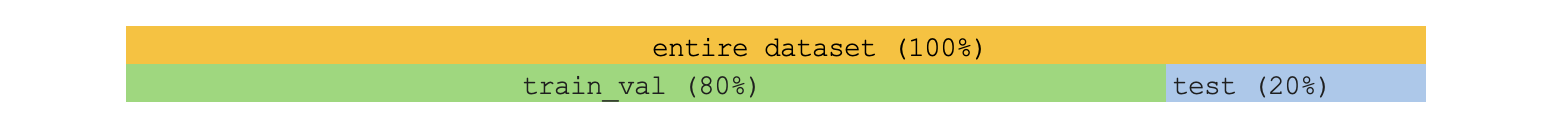

Scale the features:

In [31]:
feature_cols = X_train_val.columns.tolist()

In [32]:
calendar_cols = ['days_from_start', 'day_of_week',
                 'day_of_month', 'week_of_year']

numeric_cols  = [c for c in feature_cols if c not in calendar_cols]

In [33]:
numeric_cols

['lag_log_rv5_var_1',
 'lag_log_vix_squared_1',
 'lag_log_rv5_var_5',
 'lag_log_vix_squared_5',
 'lag_log_rv5_var_10',
 'lag_log_vix_squared_10',
 'lag_log_rv5_var_22',
 'lag_log_vix_squared_22']

In [34]:
train_val_means = X_train_val[numeric_cols].mean()
train_val_stds  = X_train_val[numeric_cols].std(ddof=0)

In [35]:
X_train_val_scaled = X_train_val.copy()
X_test_scaled      = X_test.copy()

In [36]:
X_train_val_scaled[numeric_cols] = (
    X_train_val[numeric_cols] - train_val_means
) / train_val_stds

X_test_scaled[numeric_cols] = (
    X_test[numeric_cols] - train_val_means
) / train_val_stds

Scale the target:

In [37]:
y_train_val_mean = y_train_val.mean()
y_train_val_std  = y_train_val.std(ddof=0)

In [38]:
y_train_val_scaled = y_train_val.copy()
y_test_scaled = y_test.copy()

In [39]:
y_train_val_scaled = (y_train_val - y_train_val_mean) / y_train_val_std
y_test_scaled = (y_test - y_train_val_mean) / y_train_val_std

# **Cross-Validation for Time Series Data**

![Chained Windows](https://raw.githubusercontent.com/Nixtla/statsforecast/main/nbs/imgs/ChainedWindows.gif)

We set k = 5, we perform a 5-fold cross-validation:

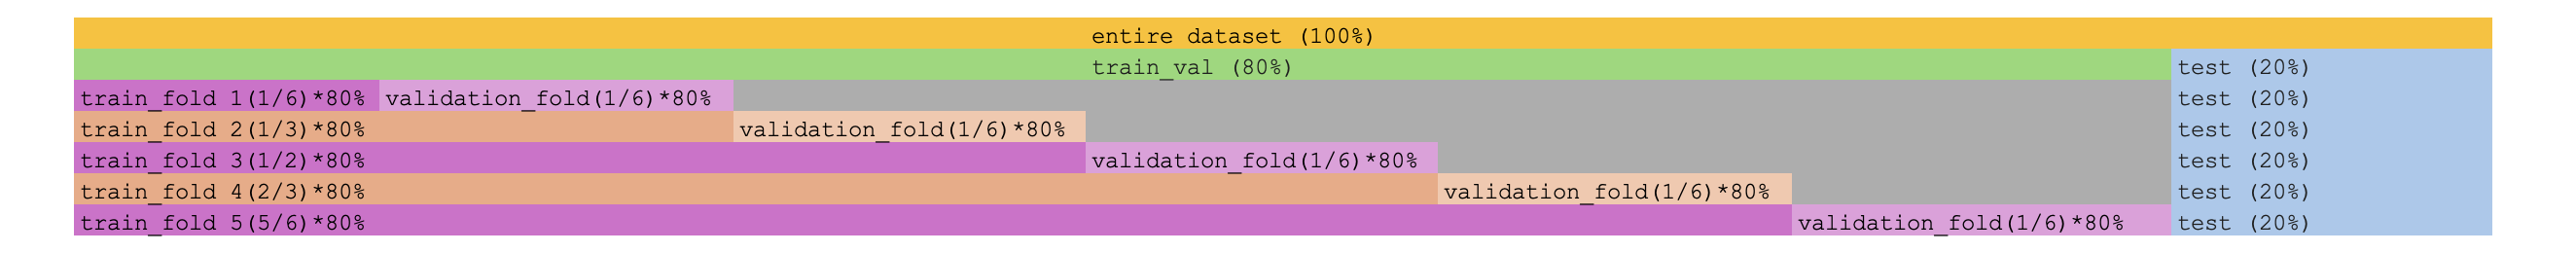

In [40]:
tscv = TimeSeriesSplit(n_splits=5)

In [41]:
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_val), 1):
  print(f"Fold {fold}")
  print(f"  Train: {train_idx}")
  print(f"  Validation: {val_idx}")

Fold 1
  Train: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 24

# **Model 1: Decision Tree**

**Parametric model**

A parametric model, such as a linear regression model, carries a predetermined number of parameters, so its degrees of freedom are limited, reducing the risk of overfitting (but increasing the risk of underfitting).

**Nonparametric model** *(ATTENTION: This is a ML specific term! In econometrics/statistics this means something else!)*:

The number of parameters is not determined prior to training, so the model structure is free to stick closely to the data.
An unconstrained
decision tree illustrates this clearly: given sufficient depth and
no minimum node size, it will recursively partition the training data
until every leaf contains a single observation, achieving zero
in-sample error.
SO...If left unconstrained, the tree structure will adapt itself to the training data, fitting it very closely: overfitting = low bias at the cost of very high variance.

**AS USUAL... A TRADE-OFF BETWEEN MEAN AND VARIANCE WILL EXIST!**

| Model type | Bias | Variance | Risk |
|---|---|---|---|
| Parametric (linear regression, fixed structure) | High bias | Low variance | Underfitting |
| Nonparametric (unconstrained tree) | Low bias | High variance | Overfitting |

**We want to reduce the risk of overfitting...**

**Pruning** is the generic term
for any technique that limits tree complexity, trading some bias for a
reduction in variance.

*1) Pre-pruning*

Pre-pruning constrains tree growth while it is being built by
imposing stopping rules on the splitting procedure. We tune two hyperparameters that act as pre-pruning
devices:

*   `max_depth` $⟶$ the maximum number of levels from the tree’s root node down to its deepest leaf. Shallow trees: high-bias vs. deep trees: high vairance. When we set the `max_depth` to `None` then:
a) tree is grown until all leaves are pure (which in practice for continuous targets means each leaf contains a single observation) or b) contain fewer than `min_samples_split` samples

*   `min_samples_split` $⟶$ the minimum number of training samples that a node must have before it’s allowed to split. In other words, it enforces a minimum number of training observations that a node
must contain before it is eligible to be split further. Larger values prevent the tree from creating very small, data-specific partitions in sparse regions of the feature space.

**N.B.** Although pre-pruning is computationally cheap,
note that it is ``too short-sighted'': a split that appears useless
in isolation may enable highly informative splits two or three levels
below it, so greedy stopping can discard genuinely useful structure.

*2) Post-pruning (Cost-Complexity Pruning)*

Post-pruning first grows the maximal tree $T_0$, then collapses internal nodes by minimising the cost-complexity criterion $C_\alpha(T) = \sum_{m=1}^{|T|} N_m Q_m(T) + \alpha|T|$, which penalises both training error and tree size so that larger $\alpha$ yields smaller subtrees. The optimal subtree is found by **weakest-link** pruning: nodes are collapsed in order of the smallest per-node error increase, producing a sequence $T_0 \supset T_1 \supset \cdots \supset T_K$ with corresponding complexity values $\alpha_0 < \alpha_1 < \cdots < \alpha_K$ returned by `cost_complexity_pruning_path()`. The optimal $\alpha^*$ is then selected by choosing the value that minimises the average validation MSE across the five time-series cross-validation folds.

*What do we do?*

In our implementation pre-pruning is the primary regularisation strategy. Pre-pruning parameters control the bias-variance tradeoff, but the optimal point on that tradeoff depends entirely on the data.



*The grid search tunes `max_depth` and `min_samples_split` simultaneously with `TimeSeriesSplit` cross-validation.*

In [42]:
dt_param_grid = {
    "max_depth": [2, 3, 5, 10, None],
    "min_samples_split": [2, 10, 50, 100]
}
dt_results = []

*What does the grid search actually do ?*

Within each fold the scaler is re-fitted exclusively on the training portion to prevent information leakage from the validation set. The combination that minimises the average MSE across the five folds is selected and used to train the final model on train+val set.

 It empirically estimates the generalisation error for each combination using held-out validation data. For **example**...


| `max_depth` | `min_samples_split` | Avg validation MSE (across the 5 folds!)|
|---|---|---|
| 2 | 2 | 0.51 |
| 2 | 10 | 0.48 |
| 2 | 50 | 0.47 |
| 2 | 100 | 0.46 |
| 3 | 2 | 0.44 |
| 3 | 10 | 0.42 |
| 3 | 50 | 0.39 |
| 3 | 100 | 0.40 |
| 5 | 2 | 0.41 |
| **5** | **10** | **0.38 ← best** |
| 5 | 50 | 0.41 |
| 5 | 100 | 0.43 |
| 10 | 2 | 0.45 |
| 10 | 10 | 0.44 |
| 10 | 50 | 0.42 |
| 10 | 100 | 0.43 |
| None | 2 | 0.52 |
| None | 10 | 0.49 |
| None | 50 | 0.46 |
| None | 100 | 0.45 |

**Note:** the MSE values are **illustrative** only but we expect to see a similar pattern to that shown above: very shallow trees underfit, unconstrained trees overfit, intermediate depth wins.

**The validation MSE is a proxy for out-of-sample performance: the grid search finds the combination that generalises best to your specific data, without ever touching the test set.**

In [43]:
for max_depth in dt_param_grid["max_depth"]:
    for min_samples_split in dt_param_grid["min_samples_split"]:
      fold_mses = []
      for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_val), 1):

        #Prepare the various datasets
        X_train_fold, X_validation_fold = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
        y_train_fold, y_validation_fold = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]

        #Scale correctly the features (numeric only)
        X_train_fold_mean = X_train_fold[numeric_cols].mean()
        X_train_fold_std  = X_train_fold[numeric_cols].std(ddof=0)
        X_train_fold_scaled = X_train_fold.copy()
        X_validation_fold_scaled = X_validation_fold.copy()
        X_train_fold_scaled[numeric_cols] = (X_train_fold[numeric_cols] - X_train_fold_mean) / X_train_fold_std
        X_validation_fold_scaled[numeric_cols] = (X_validation_fold[numeric_cols] - X_train_fold_mean) / X_train_fold_std

        #Scale correctly the target
        y_train_fold_mean = y_train_fold.mean()
        y_train_fold_std  = y_train_fold.std(ddof=0)
        y_train_fold_scaled = (y_train_fold - y_train_fold_mean) / y_train_fold_std
        y_validation_fold_scaled = (y_validation_fold - y_train_fold_mean) / y_train_fold_std

        #Train the model for combination of hyperparameters + fold
        model = DecisionTreeRegressor(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
        model.fit(X_train_fold_scaled, y_train_fold_scaled)

        #Predict
        y_pred_scaled = model.predict(X_validation_fold_scaled)

        #Inverse-scale the predictions
        y_pred = y_pred_scaled * y_train_fold_std + y_train_fold_mean

        #Calculate the MSE for the fold
        fold_mses.append(mean_squared_error(y_validation_fold, y_pred))

      #Average the MSE over folds
      avg_mse = np.mean(fold_mses)
      dt_results.append({
            "model": "DecisionTree",
            "max_depth": max_depth,
            "min_samples_split": min_samples_split,
            "average mse across 5 folds": avg_mse
        })

dt_results_df = pd.DataFrame(dt_results)
best_dt = dt_results_df.loc[dt_results_df["average mse across 5 folds"].idxmin()]
print("Best DecisionTreeRegressor hyperparameters:")
print(best_dt)

Best DecisionTreeRegressor hyperparameters:
model                         DecisionTree
max_depth                              5.0
min_samples_split                       50
average mse across 5 folds         0.28323
Name: 10, dtype: object


**Final Model**

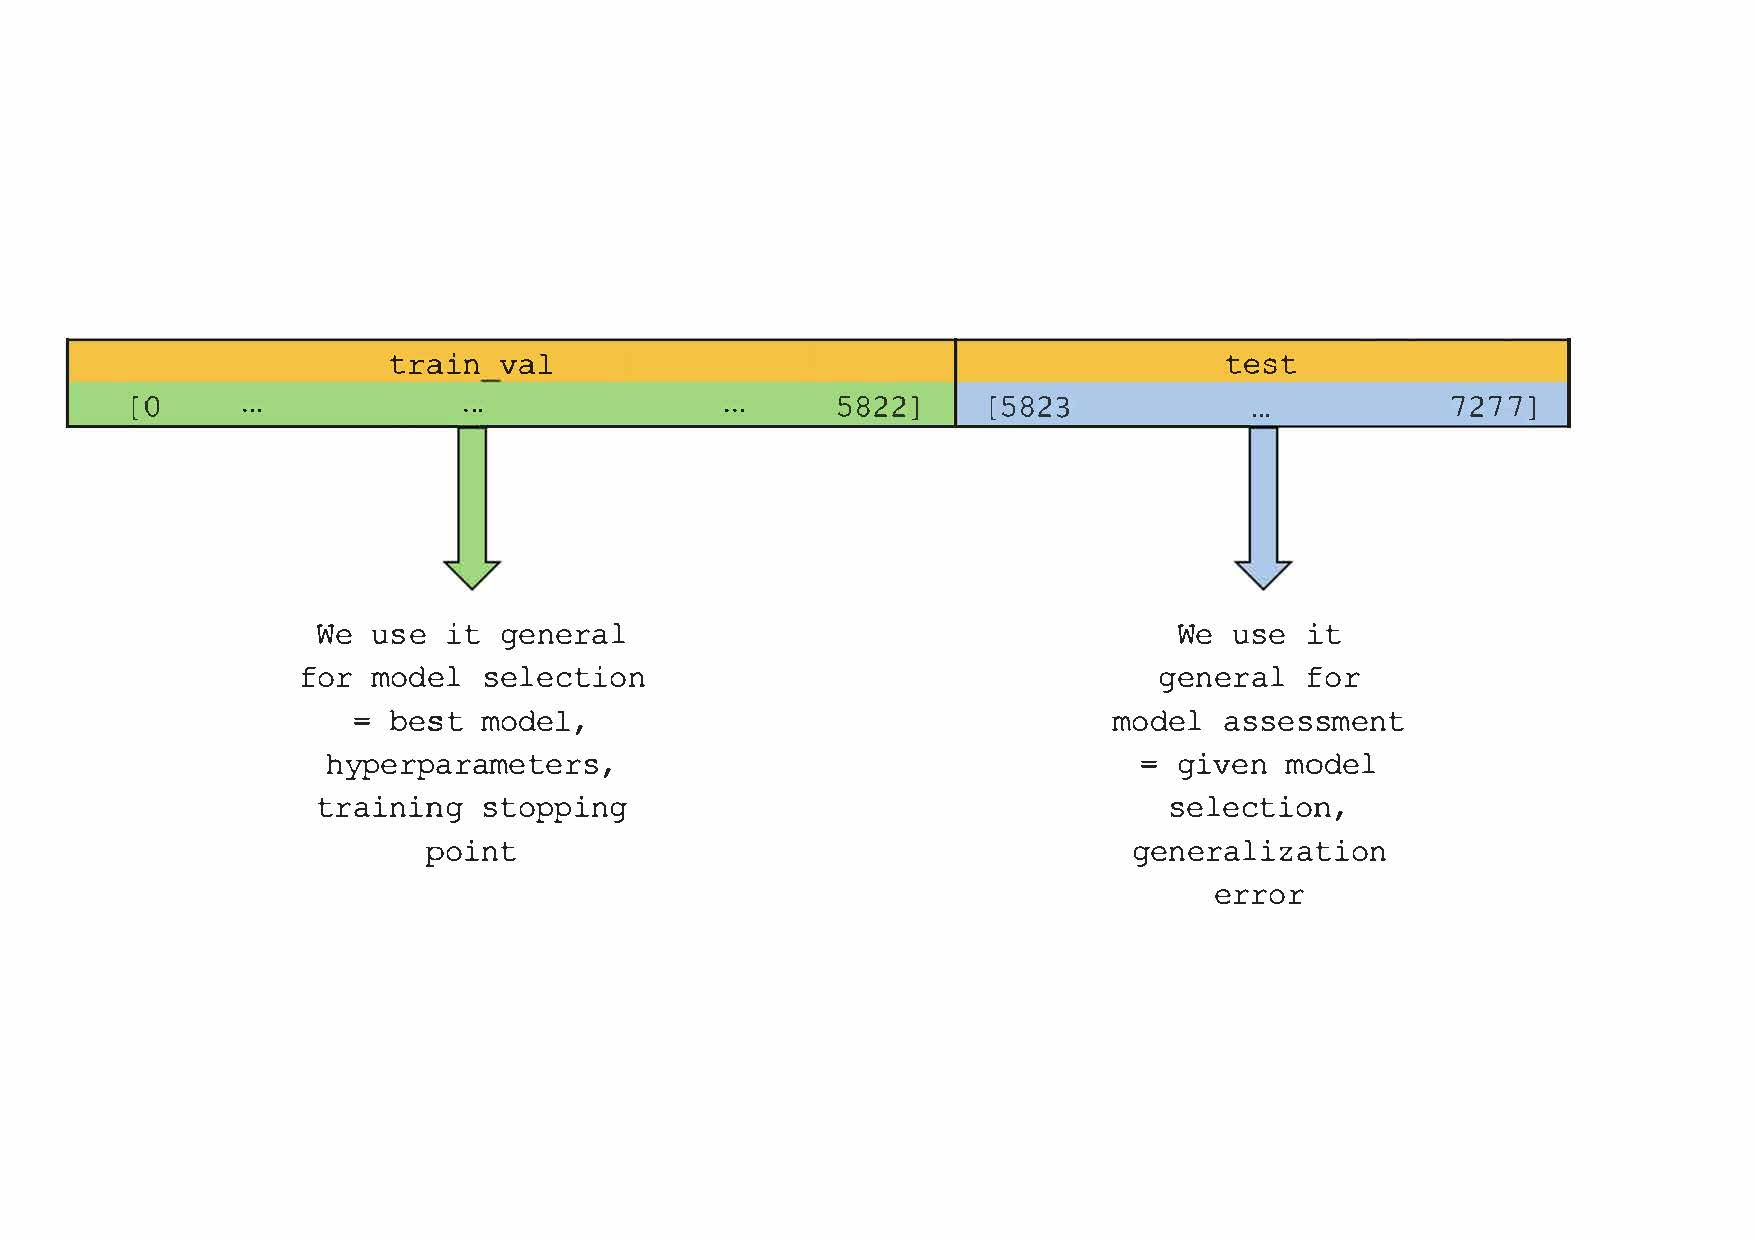

In [44]:
start_idx_test = X_test_scaled.index[0]
end_idx_test   = X_test_scaled.index[-1]
df_rv5_var_test= df_rv5_var.loc[start_idx_test + 1 : end_idx_test]
print(f"  [   {start_idx_test + 1} . . . {end_idx_test}   ]")

  [   5823 . . . 7277   ]


In [45]:
end_idx_test - (start_idx_test + 1) + 1

np.int64(1455)

In [46]:
# Decision Tree Final Model
final_dt = DecisionTreeRegressor(
    max_depth=int(best_dt['max_depth']),
    min_samples_split=best_dt['min_samples_split'],
    random_state=42
)

final_dt.fit(X_train_val_scaled, y_train_val_scaled)
y_pred_dt_test_scaled = final_dt.predict(X_test_scaled)
y_pred_dt_test = y_pred_dt_test_scaled * y_train_val_std + y_train_val_mean

In [47]:
len(X_test_scaled)

1456

In [48]:
forecasts_final_dt= pd.DataFrame(y_pred_dt_test)
forecasts_final_dt= forecasts_final_dt[0:1455]

In [49]:
forecasts_final_dt.rename(columns={0: 'forecasts_final_dt'}, inplace=True)
forecasts_final_dt = forecasts_final_dt.join(df_rv5_var_test.reset_index(drop=True))
forecasts_final_dt['adjusted_forecasts_final_dt'] = np.exp(forecasts_final_dt["forecasts_final_dt"]+1/2*np.var(forecasts_final_dt["forecasts_final_dt"]))

In [50]:
forecasts_final_dt.set_index('ds', inplace=True)
forecasts_final_dt['adjusted_forecasts_final_dt'].value_counts()

,count
adjusted_forecasts_final_dt,
0.529480,164
0.379849,162
0.852369,161
2.114745,102
0.850510,99
1.086923,99
0.294074,98
0.616593,95
1.588615,84


In [51]:
forecast_errors_final_dt = forecasts_final_dt['adjusted_forecasts_final_dt'] - forecasts_final_dt['rv5_var']

In [52]:
forecast_errors_final_dt

,0
ds,
2019-04-04,0.002374
2019-04-05,0.165384
2019-04-08,0.185808
2019-04-09,0.047953
2019-04-10,0.071940
...,...
2025-04-23,-1.861434
2025-04-24,1.326678
2025-04-25,1.824357


In [53]:
RMSFE_dt = np.sqrt(np.mean(np.array(forecast_errors_final_dt)**2))
RMSFE_dt

np.float64(1.2793900389917932)

In [54]:
rel_RMSFE_dt = RMSFE_dt/RMSFE_garch
rel_RMSFE_dt

np.float64(0.5564570083880572)

**N.B.!! Recall we are dealing with z-scores of log RV₅**

In [55]:
def get_tree_structure(tree_model, feature_names):
    """Extract tree structure into nodes/edges for Plotly."""
    tree_ = tree_model.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "leaf"
        for i in tree_.feature
    ]

    nodes, edges = [], []

    def recurse(node, depth, x, x_min, x_max, y_step=1.5):
        n_samples = tree_.n_node_samples[node]
        mse = tree_.impurity[node]
        value = tree_.value[node][0][0]

        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            label = (
                f"<b>{feature_name[node]}</b><br>"
                f"≤ {tree_.threshold[node]:.3f}<br>"
                f"MSE = {mse:.3f}<br>"
                f"n = {n_samples}<br>"
                f"val = {value:.3f}"
            )
            color = "rgba(230,160,80,0.9)"
        else:
            label = (
                f"<b>LEAF</b><br>"
                f"MSE = {mse:.3f}<br>"
                f"n = {n_samples}<br>"
                f"val = {value:.3f}"
            )
            color = "rgba(100,180,100,0.9)"

        nodes.append(dict(x=x, y=-depth, label=label, color=color, node_id=node))

        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            x_mid_left  = (x_min + x) / 2
            x_mid_right = (x + x_max) / 2

            left_child  = tree_.children_left[node]
            right_child = tree_.children_right[node]

            edges.append((x, -depth, x_mid_left,  -(depth + y_step), "True"))
            edges.append((x, -depth, x_mid_right, -(depth + y_step), "False"))

            recurse(left_child,  depth + y_step, x_mid_left,  x_min, x, y_step)
            recurse(right_child, depth + y_step, x_mid_right, x,     x_max, y_step)

    recurse(0, 0, 0.5, 0.0, 1.0, y_step=1.5)
    return nodes, edges


nodes, edges = get_tree_structure(final_dt, feature_cols)

fig = go.Figure()

# Draw edges
for (x0, y0, x1, y1, label) in edges:
    fig.add_trace(go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode="lines",
        line=dict(color="gray", width=1),
        hoverinfo="none",
        showlegend=False
    ))
    fig.add_annotation(
        x=(x0 + x1) / 2, y=(y0 + y1) / 2,
        text=f"<b>{label}</b>",
        showarrow=False,
        font=dict(size=9, color="black"),
        bgcolor="white",
        opacity=0.7
    )

# Draw nodes
for node in nodes:
    fig.add_trace(go.Scatter(
        x=[node["x"]], y=[node["y"]],
        mode="markers+text",
        marker=dict(size=35, color=node["color"],
                    line=dict(color="black", width=1)),
        text=[""],
        hovertext=node["label"],
        hoverinfo="text",
        showlegend=False
    ))
    fig.add_annotation(
        x=node["x"], y=node["y"],
        text=node["label"],
        showarrow=False,
        font=dict(size=8, family="Courier New"),
        align="center",
        bgcolor=node["color"],
        bordercolor="black",
        borderwidth=1,
        borderpad=3,
        opacity=0.95
    )

fig.update_layout(
    title=dict(
        text="Decision Tree: Final Model",
        font=dict(size=20, family="Serif"),
        x=0.5
    ),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)",
    height=900,
    width=1400,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()

In [56]:
print(pd.Series(
    final_dt.feature_importances_,
    index=feature_cols
))

days_from_start           0.000000
day_of_week               0.000000
day_of_month              0.000000
week_of_year              0.002007
lag_log_rv5_var_1         0.313242
lag_log_vix_squared_1     0.650332
lag_log_rv5_var_5         0.003536
lag_log_vix_squared_5     0.000000
lag_log_rv5_var_10        0.001452
lag_log_vix_squared_10    0.000000
lag_log_rv5_var_22        0.029431
lag_log_vix_squared_22    0.000000
dtype: float64


In [57]:
fig_dt = go.Figure()

fig_dt.add_trace(go.Scatter(
    x=forecasts_final_dt.index,
    y=forecasts_final_dt['adjusted_forecasts_final_dt'],
    mode='lines',
    name='Adjusted Forecasts (DT)',
    line=dict(color='steelblue', width=3)
))

fig_dt.add_trace(go.Scatter(
    x=forecasts_final_dt.index,
    y=forecasts_final_dt['rv5_var'],
    mode='lines',
    name='RV<sub>5</sub>',
    line=dict(color='firebrick', width=0.5)
))

fig_dt.update_layout(
    title=dict(
        text=f'Decision Tree Predicted Variance',
        x=0.5,
        font=dict(size=30, family='Serif', color='black')
    ),
    xaxis=dict(
        title='Date',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False
    ),
    yaxis=dict(
        title='Variance',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False,
        zeroline=False,
    ),
    font=dict(
        family="Serif",
        size=20,
        color="black"
    ),

    plot_bgcolor='rgba(0,0,0,0)',

    paper_bgcolor='rgba(0,0,0,0)',

    legend=dict(
        font=dict(size=18),
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='black',
        borderwidth=1
    ),
    margin=dict(t=80, l=60, r=60, b=60)
)

fig_dt.show()

# **Model 2: Random Forest (Bagging)**

| **Value** | **Features considered per split** | **Effect** |
|---|---|---|
| `"sqrt"` | $m = \sqrt{p}$ | Breiman's original recommendation for classification |
| `"log2"` | $m = \log_2(p)$ | More aggressive — fewer features, more randomness |
| `0.5` | $m = p/2$ | Less aggressive — more features, less randomness |

In [58]:
rf_param_grid = {
    "max_depth"        : [3, 5, 10, None],
    "min_samples_split": [10, 50, 100],
    "n_estimators"     : [10, 15, 20],
    "max_features"     : ["sqrt", "log2", 0.5]
}
rf_results = []

In [59]:
for max_depth in rf_param_grid["max_depth"]:
  for min_samples_split in rf_param_grid["min_samples_split"]:
    for n_estimators in rf_param_grid["n_estimators"]:
      for max_features in rf_param_grid["max_features"]:
        fold_mses = []
        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_val), 1):
            # Prepare the various datasets
            X_train_fold, X_validation_fold = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
            y_train_fold, y_validation_fold = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]

            # Scale correctly the features (numeric only)
            X_train_fold_mean = X_train_fold[numeric_cols].mean()
            X_train_fold_std  = X_train_fold[numeric_cols].std(ddof=0)
            X_train_fold_scaled = X_train_fold.copy()
            X_validation_fold_scaled = X_validation_fold.copy()
            X_train_fold_scaled[numeric_cols] = (X_train_fold[numeric_cols] - X_train_fold_mean) / X_train_fold_std
            X_validation_fold_scaled[numeric_cols] = (X_validation_fold[numeric_cols] - X_train_fold_mean) / X_train_fold_std

            # Scale correctly the target
            y_train_fold_mean = y_train_fold.mean()
            y_train_fold_std  = y_train_fold.std(ddof=0)
            y_train_fold_scaled = (y_train_fold - y_train_fold_mean) / y_train_fold_std
            y_validation_fold_scaled = (y_validation_fold - y_train_fold_mean) / y_train_fold_std

            # Train the model for this combination of hyperparameters + fold
            model = RandomForestRegressor(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                n_estimators=n_estimators,
                max_features=max_features,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_train_fold_scaled, y_train_fold_scaled)

            # Predict
            y_pred_scaled = model.predict(X_validation_fold_scaled)

            # Inverse-scale the predictions
            y_pred = y_pred_scaled * y_train_fold_std + y_train_fold_mean

            # Calculate the MSE for the fold
            fold_mses.append(mean_squared_error(y_validation_fold, y_pred))

        # Average the MSE over folds
        avg_mse = np.mean(fold_mses)
        rf_results.append({
            "model": "RandomForest",
            "max_depth": max_depth,
            "min_samples_split": min_samples_split,
            "n_estimators": n_estimators,
            "max_features": max_features,
            "average mse across 5 folds": avg_mse
        })

rf_results_df = pd.DataFrame(rf_results)
best_rf = rf_results_df.loc[rf_results_df["average mse across 5 folds"].idxmin()]
print("\nBest RandomForestRegressor hyperparameters:")
print(best_rf)


Best RandomForestRegressor hyperparameters:
model                         RandomForest
max_depth                             10.0
min_samples_split                       50
n_estimators                            10
max_features                           0.5
average mse across 5 folds        0.243313
Name: 65, dtype: object


**Final Model**

In [60]:
start_idx_test = X_test_scaled.index[0]
end_idx_test   = X_test_scaled.index[-1]
df_epsilon_squared_test= df_rv5_var.loc[start_idx_test + 1 : end_idx_test]
print(f"  [   {start_idx_test + 1} . . . {end_idx_test}   ]")

  [   5823 . . . 7277   ]


In [61]:
# Random Forest Final Model
if pd.isna(best_rf['max_depth']):   # treat NaN as None
    max_depth = None
else:
    max_depth = int(best_rf['max_depth'])

final_rf = RandomForestRegressor(
    max_depth=max_depth,
    min_samples_split=int(best_rf['min_samples_split']),
    n_estimators=int(best_rf['n_estimators']),
    random_state=42,
    n_jobs=-1
)

# Fit and predict
final_rf.fit(X_train_val_scaled, y_train_val_scaled)
y_pred_rf_test_scaled = final_rf.predict(X_test_scaled)

# Rescale predictions back
y_pred_rf_test = y_pred_rf_test_scaled * y_train_val_std + y_train_val_mean

In [62]:
forecasts_final_rf= pd.DataFrame(y_pred_rf_test)
forecasts_final_rf= forecasts_final_rf[0:1455]

In [63]:
forecasts_final_rf.rename(columns={0: 'forecasts_final_rf'}, inplace=True)
forecasts_final_rf = forecasts_final_rf.join(df_rv5_var_test.reset_index(drop=True))
forecasts_final_rf['adjusted_forecasts_final_rf'] = np.exp(forecasts_final_rf["forecasts_final_rf"]+1/2*np.var(forecasts_final_rf["forecasts_final_rf"]))

In [64]:
forecasts_final_rf.set_index('ds', inplace=True)
forecasts_final_rf['adjusted_forecasts_final_rf'].value_counts()

,count
adjusted_forecasts_final_rf,
20.839711,7
0.641389,6
0.585201,5
0.659469,4
0.377356,4
...,...
0.812136,1
2.089390,1
2.494470,1


In [65]:
forecast_errors_final_rf = forecasts_final_rf['adjusted_forecasts_final_rf'] - forecasts_final_rf['rv5_var']

In [66]:
RMSFE_rf = np.sqrt(np.mean(np.array(forecast_errors_final_rf)**2))
RMSFE_rf

np.float64(1.2100866308277036)

In [67]:
rel_RMSFE_rf = RMSFE_rf/RMSFE_garch
rel_RMSFE_rf

np.float64(0.5263142325317782)

In [68]:
forecasts_final_rf

,forecasts_final_rf,vix_squared,rv5_var,adjusted_forecasts_final_rf
ds,,,,
2019-04-04,-1.748090,0.731811,0.206158,0.258142
2019-04-05,-1.551162,0.652192,0.128690,0.314328
2019-04-08,-1.673190,0.689335,0.108266,0.278219
2019-04-09,-1.884064,0.809200,0.160579,0.225323
2019-04-10,-1.828840,0.701944,0.136592,0.238116
...,...,...,...,...
2025-04-23,0.323405,3.211915,3.450049,2.048790
2025-04-24,0.519651,2.780400,0.788067,2.493021
2025-04-25,0.692208,2.448514,1.038525,2.962557


In [69]:
fig_rf = go.Figure()

fig_rf.add_trace(go.Scatter(
    x=forecasts_final_rf.index,
    y=forecasts_final_rf['adjusted_forecasts_final_rf'],
    mode='lines',
    name='Adjusted Forecasts (RF)',
    line=dict(color='steelblue', width=3)
))

fig_rf.add_trace(go.Scatter(
    x=forecasts_final_dt.index,
    y=forecasts_final_dt['rv5_var'],
    mode='lines',
    name='RV<sub>5</sub>',
    line=dict(color='firebrick', width=0.5)
))

fig_rf.update_layout(
    title=dict(
        text=f'Random Forest Predicted Variance',
        x=0.5,
        font=dict(size=30, family='Serif', color='black')
    ),
    xaxis=dict(
        title='Date',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False
    ),
    yaxis=dict(
        title='Variance',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False,
        zeroline=False,
    ),
    font=dict(
        family="Serif",
        size=20,
        color="black"
    ),

    plot_bgcolor='rgba(0,0,0,0)',

    paper_bgcolor='rgba(0,0,0,0)',

    legend=dict(
        font=dict(size=18),
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='black',
        borderwidth=1
    ),
    margin=dict(t=80, l=60, r=60, b=60)
)

fig_rf.show()

# **Who wins (until now)?**

In [70]:
RMSFE_garch

np.float64(2.29917139995761)

In [71]:
RMSFE_threshold_garch

np.float64(2.363497170520806)

In [72]:
RMSFE_tstud_threshold_garch

np.float64(2.6505076919647714)

In [73]:
RMSFE_fixed_aparch

np.float64(1.8360339215547623)

In [74]:
RMSFE_dt

np.float64(1.2793900389917932)

In [75]:
RMSFE_rf

np.float64(1.2100866308277036)